# 05 — Ensemble e Geração da Submissão Final
## DengAI: Predicting Disease Spread

Neste notebook combinamos os melhores modelos dos notebooks anteriores num ensemble,
geramos as previsões para o conjunto de teste e produzimos o ficheiro de submissão
no formato exacto exigido pela DrivenData.


Em vez de confiar num único modelo, combinamos as previsões de vários modelos
complementares, cada um captura aspectos diferentes dos dados (não-linearidades,
dependências temporais, sazonalidade). A combinação reduz a variância das previsões
e tende a superar o melhor modelo individual.

Usamos **média ponderada**: os modelos com menor MAE de CV recebem maior peso.




In [1]:
import pandas as pd                                      # DataFrames
import numpy as np                                       # ensemble, clip, expm1
import matplotlib.pyplot as plt                          # visualizações
import seaborn as sns                                    # distribuições
import warnings, pickle                                  # utilidades
from sklearn.ensemble import RandomForestRegressor       # Random Forest
from sklearn.model_selection import TimeSeriesSplit      # CV temporal
from sklearn.metrics import mean_absolute_error          # MAE
from xgboost import XGBRegressor                         # XGBoost
from lightgbm import LGBMRegressor                       # LightGBM

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})

# Carregar dados
train_sj = pd.read_csv('database/processed/train_sj.csv')
train_iq = pd.read_csv('database/processed/train_iq.csv')
test_sj  = pd.read_csv('database/processed/test_sj.csv')
test_iq  = pd.read_csv('database/processed/test_iq.csv')
submission_format = pd.read_csv('database/submission_format.csv')

excluir   = ['city', 'year', 'weekofyear', 'week_start_date', 'total_cases', 'total_cases_log']
feat_cols = [c for c in train_sj.columns if c not in excluir]

X_train_sj = train_sj[feat_cols].values
y_train_sj = train_sj['total_cases_log'].values
y_orig_sj  = train_sj['total_cases'].values

X_train_iq = train_iq[feat_cols].values
y_train_iq = train_iq['total_cases_log'].values
y_orig_iq  = train_iq['total_cases'].values

X_test_sj  = test_sj[feat_cols].values
X_test_iq  = test_iq[feat_cols].values

print(f"Dados carregados — Treino SJ: {X_train_sj.shape}, Treino IQ: {X_train_iq.shape}")
print(f"Dados de teste  — Teste  SJ: {X_test_sj.shape},  Teste  IQ: {X_test_iq.shape}")


Dados carregados — Treino SJ: (932, 80), Treino IQ: (516, 80)
Dados de teste  — Teste  SJ: (260, 80),  Teste  IQ: (156, 80)


### 1. Treino dos Modelos Finais no Dataset Completo

Nos notebooks anteriores, os modelos foram avaliados em cross-validation para obter
estimativas de MAE. Agora treinamos cada modelo no **dataset completo de treino**
(todos os folds), para maximizar a informação disponível na fase de previsão.

Este é o procedimento padrão: CV para selecção de hiperparâmetros e estimativa de
desempenho, treino completo para a previsão final.

Definimos os hiperparâmetros com base nos melhores resultados da GridSearchCV do notebook 04_Advanced_Models.ipynb


In [2]:
# ── Parâmetros finais (melhores encontrados no NB4) ──────────────────────────
# Estes valores devem ser substituídos pelos params_xgb_sj/iq do NB4 quando executado

XGB_PARAMS_SJ  = dict(n_estimators=400, max_depth=3, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                       reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0)
XGB_PARAMS_IQ  = dict(n_estimators=400, max_depth=5, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                       reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0)
LGBM_PARAMS_SJ = dict(n_estimators=400, max_depth=4, learning_rate=0.05,
                       num_leaves=15, min_child_samples=10,
                       subsample=0.8, colsample_bytree=0.8,
                       reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1)
LGBM_PARAMS_IQ = dict(n_estimators=400, max_depth=6, learning_rate=0.05,
                       num_leaves=31, min_child_samples=10,
                       subsample=0.8, colsample_bytree=0.8,
                       reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1)
RF_PARAMS      = dict(n_estimators=200, max_depth=10, min_samples_leaf=5,
                       random_state=42, n_jobs=-1)

# ── Treinar modelos completos ──────────────────────────────────────────────
print("── A treinar modelos no dataset completo ──")

xgb_sj_final  = XGBRegressor(**XGB_PARAMS_SJ).fit(X_train_sj, y_train_sj)
xgb_iq_final  = XGBRegressor(**XGB_PARAMS_IQ).fit(X_train_iq, y_train_iq)
lgbm_sj_final = LGBMRegressor(**LGBM_PARAMS_SJ).fit(X_train_sj, y_train_sj)
lgbm_iq_final = LGBMRegressor(**LGBM_PARAMS_IQ).fit(X_train_iq, y_train_iq)
rf_sj_final   = RandomForestRegressor(**RF_PARAMS).fit(X_train_sj, y_train_sj)
rf_iq_final   = RandomForestRegressor(**RF_PARAMS).fit(X_train_iq, y_train_iq)

print("  XGBoost SJ  ")
print("  XGBoost IQ  ")
print("  LightGBM SJ ")
print("  LightGBM IQ ")
print("  RF SJ       ")
print("  RF IQ       ")
print("\nTodos os modelos treinados no dataset completo.")


── A treinar modelos no dataset completo ──
  XGBoost SJ  
  XGBoost IQ  
  LightGBM SJ 
  LightGBM IQ 
  RF SJ       
  RF IQ       

Todos os modelos treinados no dataset completo.


### 2. Estimativa de MAE para Calcular Pesos do Ensemble

Para definir os pesos da média ponderada, precisamos de uma estimativa de MAE
por modelo. Usamos o MAE do último fold do TimeSeriesSplit (o fold mais próximo
do período de teste em termos temporais), é a estimativa mais representativa
do desempenho real na previsão de futuro.


Um modelo com MAE=15 merece mais peso do que um com MAE=25, em vez de contribuírem igualmente.


In [3]:
N_FOLDS = 5
tscv = TimeSeriesSplit(n_splits=N_FOLDS)

def mae_ultimo_fold(X, y_log, y_orig, modelo_cls, params):
    """Avalia MAE no último fold temporal (mais representativo da previsão futura)."""
    folds = list(tscv.split(X))
    tr_idx, te_idx = folds[-1]  # último fold
    modelo = modelo_cls(**params)
    modelo.fit(X[tr_idx], y_log[tr_idx])
    preds = np.maximum(np.expm1(modelo.predict(X[te_idx])), 0)
    return mean_absolute_error(y_orig[te_idx], preds)

print("── MAE no último fold (estimativa para pesos do ensemble) ──\n")

mae_xgb_sj  = mae_ultimo_fold(X_train_sj, y_train_sj, y_orig_sj, XGBRegressor,  XGB_PARAMS_SJ)
mae_lgbm_sj = mae_ultimo_fold(X_train_sj, y_train_sj, y_orig_sj, LGBMRegressor, LGBM_PARAMS_SJ)
mae_rf_sj   = mae_ultimo_fold(X_train_sj, y_train_sj, y_orig_sj, RandomForestRegressor, RF_PARAMS)

mae_xgb_iq  = mae_ultimo_fold(X_train_iq, y_train_iq, y_orig_iq, XGBRegressor,  XGB_PARAMS_IQ)
mae_lgbm_iq = mae_ultimo_fold(X_train_iq, y_train_iq, y_orig_iq, LGBMRegressor, LGBM_PARAMS_IQ)
mae_rf_iq   = mae_ultimo_fold(X_train_iq, y_train_iq, y_orig_iq, RandomForestRegressor, RF_PARAMS)

print(f"  SJ — XGBoost:  MAE = {mae_xgb_sj:.2f}")
print(f"  SJ — LightGBM: MAE = {mae_lgbm_sj:.2f}")
print(f"  SJ — RF:       MAE = {mae_rf_sj:.2f}")
print(f"\n  IQ — XGBoost:  MAE = {mae_xgb_iq:.2f}")
print(f"  IQ — LightGBM: MAE = {mae_lgbm_iq:.2f}")
print(f"  IQ — RF:       MAE = {mae_rf_iq:.2f}")

# Pesos inversamente proporcionais ao MAE: w_i = 1/MAE_i, normalizados
def calcular_pesos(maes):
    """Pesos inversamente proporcionais ao MAE, normalizados para soma = 1."""
    inv = [1.0 / m if m > 0 else 0.0 for m in maes]
    total = sum(inv)
    return [w / total for w in inv]

pesos_sj = calcular_pesos([mae_xgb_sj, mae_lgbm_sj, mae_rf_sj])
pesos_iq = calcular_pesos([mae_xgb_iq, mae_lgbm_iq, mae_rf_iq])

print(f"\n── Pesos do ensemble (proporcional a 1/MAE) ──")
print(f"  SJ: XGB={pesos_sj[0]:.3f}  LGBM={pesos_sj[1]:.3f}  RF={pesos_sj[2]:.3f}")
print(f"  IQ: XGB={pesos_iq[0]:.3f}  LGBM={pesos_iq[1]:.3f}  RF={pesos_iq[2]:.3f}")


── MAE no último fold (estimativa para pesos do ensemble) ──

  SJ — XGBoost:  MAE = 19.13
  SJ — LightGBM: MAE = 19.76
  SJ — RF:       MAE = 18.43

  IQ — XGBoost:  MAE = 5.36
  IQ — LightGBM: MAE = 5.19
  IQ — RF:       MAE = 4.91

── Pesos do ensemble (proporcional a 1/MAE) ──
  SJ: XGB=0.333  LGBM=0.322  RF=0.345
  IQ: XGB=0.320  LGBM=0.330  RF=0.349


### 3. Ensemble e Previsões no Conjunto de Teste

Geramos as previsões de cada modelo no conjunto de teste e combinamos pela
média ponderada definida acima.


1. Prever com cada modelo (em escala log)
2. Transformação inversa: `expm1(pred_log)` obtnedo assim escala original
3. Média ponderada das previsões em escala original
4. Arredondar para inteiros e clipar a ≥ 0 (não pode haver casos negativos)


In [4]:
def ensemble_preds(X_test, modelos, pesos):
    """Ensemble ponderado: média das previsões em escala original."""
    preds_orig = []
    for modelo in modelos:
        p_log  = modelo.predict(X_test)
        p_orig = np.maximum(np.expm1(p_log), 0)
        preds_orig.append(p_orig)

    # Média ponderada
    ensemble = sum(w * p for w, p in zip(pesos, preds_orig))
    return ensemble

# ── Previsões para San Juan ──
preds_sj = ensemble_preds(
    X_test_sj,
    [xgb_sj_final, lgbm_sj_final, rf_sj_final],
    pesos_sj
)

# ── Previsões para Iquitos ──
preds_iq = ensemble_preds(
    X_test_iq,
    [xgb_iq_final, lgbm_iq_final, rf_iq_final],
    pesos_iq
)

# Arredondar para inteiros e garantir não-negativos
preds_sj_int = np.maximum(np.round(preds_sj).astype(int), 0)
preds_iq_int = np.maximum(np.round(preds_iq).astype(int), 0)

print("── Estatísticas das previsões finais ──\n")
print(f"  San Juan — {len(preds_sj_int)} semanas:")
print(f"    Mínimo:   {preds_sj_int.min()} casos/semana")
print(f"    Máximo:   {preds_sj_int.max()} casos/semana")
print(f"    Média:    {preds_sj_int.mean():.1f} casos/semana")
print(f"    Mediana:  {np.median(preds_sj_int):.0f} casos/semana")
print(f"    % zeros:  {(preds_sj_int == 0).mean()*100:.1f}%")

print(f"\n  Iquitos — {len(preds_iq_int)} semanas:")
print(f"    Mínimo:   {preds_iq_int.min()} casos/semana")
print(f"    Máximo:   {preds_iq_int.max()} casos/semana")
print(f"    Média:    {preds_iq_int.mean():.1f} casos/semana")
print(f"    Mediana:  {np.median(preds_iq_int):.0f} casos/semana")
print(f"    % zeros:  {(preds_iq_int == 0).mean()*100:.1f}%")


── Estatísticas das previsões finais ──

  San Juan — 260 semanas:
    Mínimo:   3 casos/semana
    Máximo:   160 casos/semana
    Média:    22.7 casos/semana
    Mediana:  16 casos/semana
    % zeros:  0.0%

  Iquitos — 156 semanas:
    Mínimo:   1 casos/semana
    Máximo:   14 casos/semana
    Média:    4.8 casos/semana
    Mediana:  4 casos/semana
    % zeros:  0.0%


### 4. Visualização das Previsões

Plotamos as previsões do período de teste sobre o histórico de treino, para
verificar se os valores previstos são plausíveis (mesma ordem de grandeza,
mesma sazonalidade) e se não há artefactos óbvios.


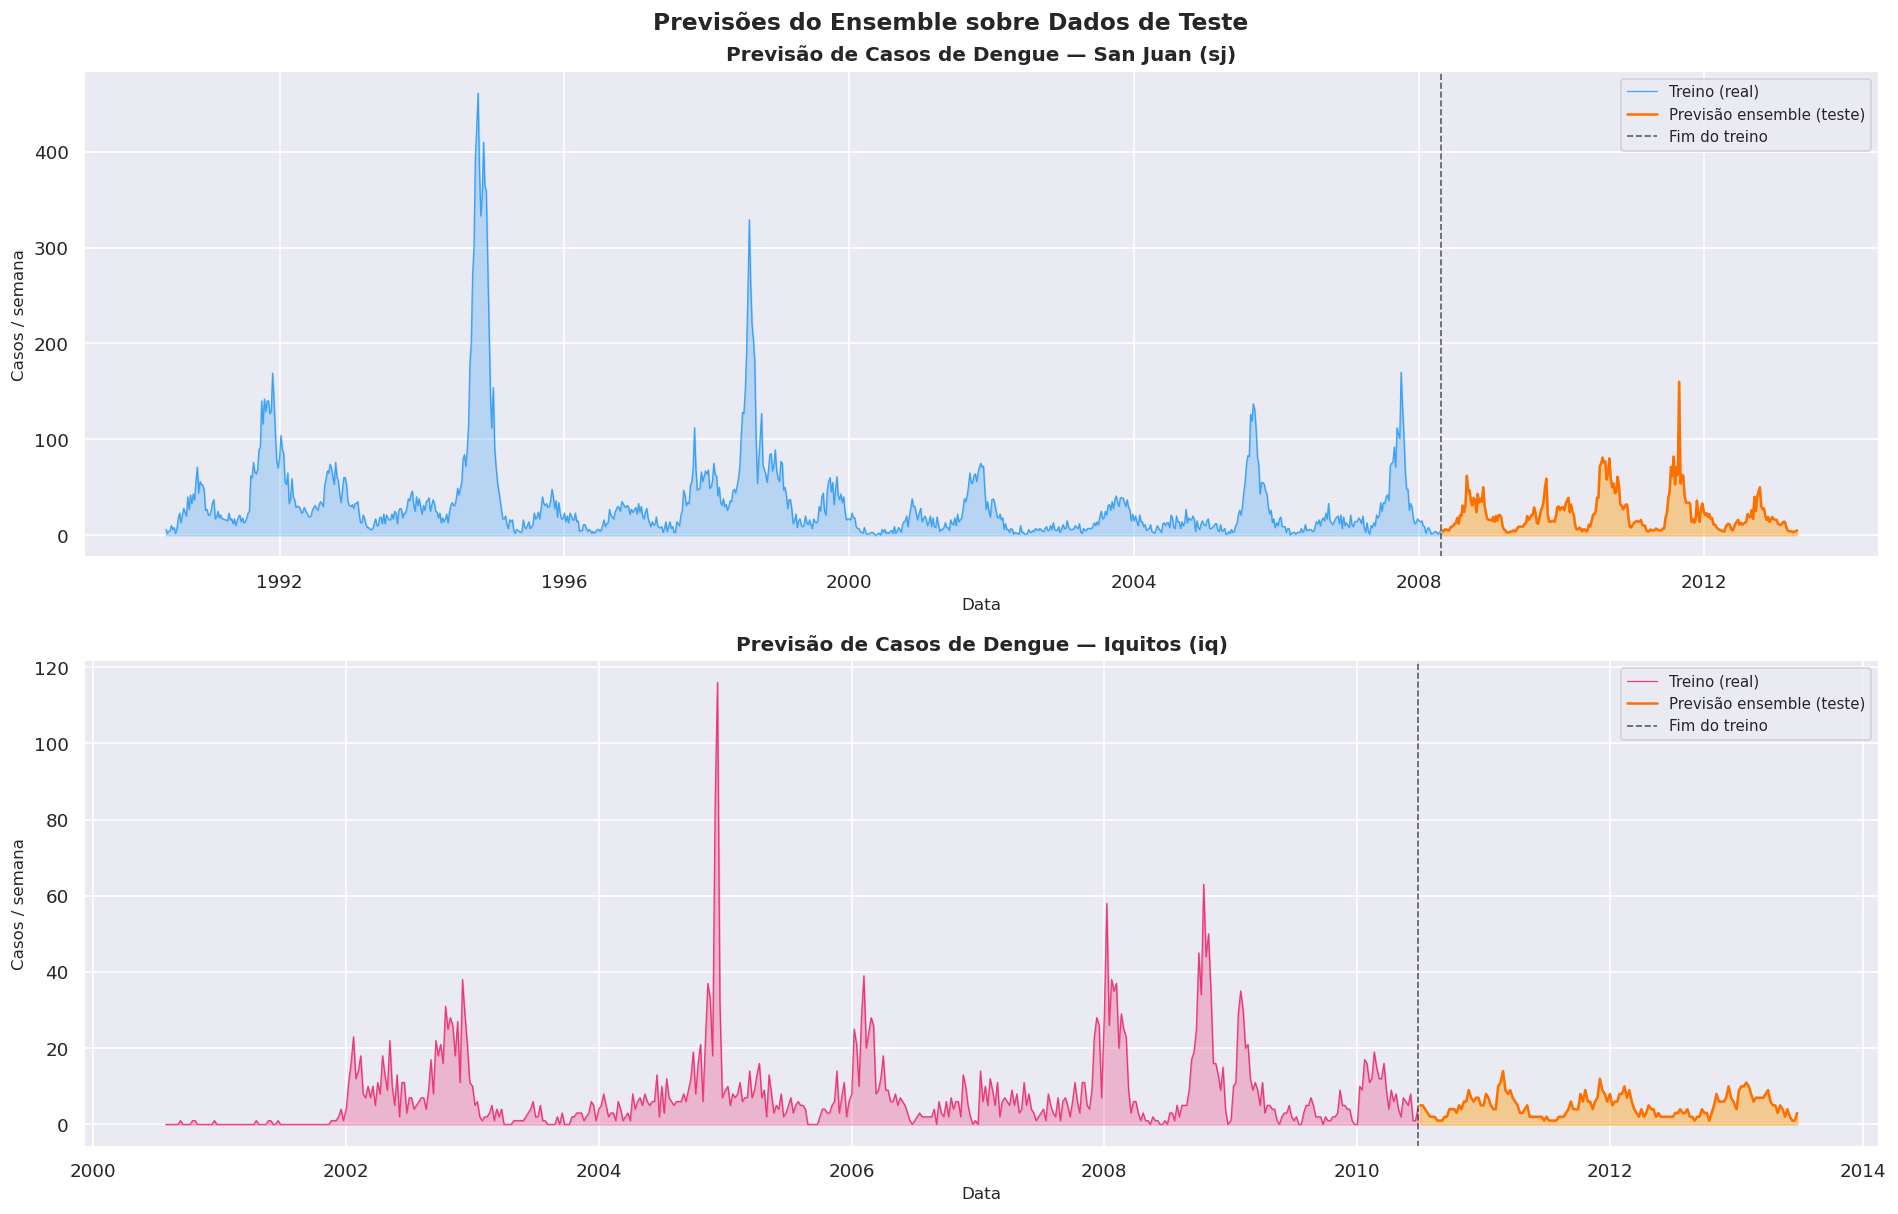

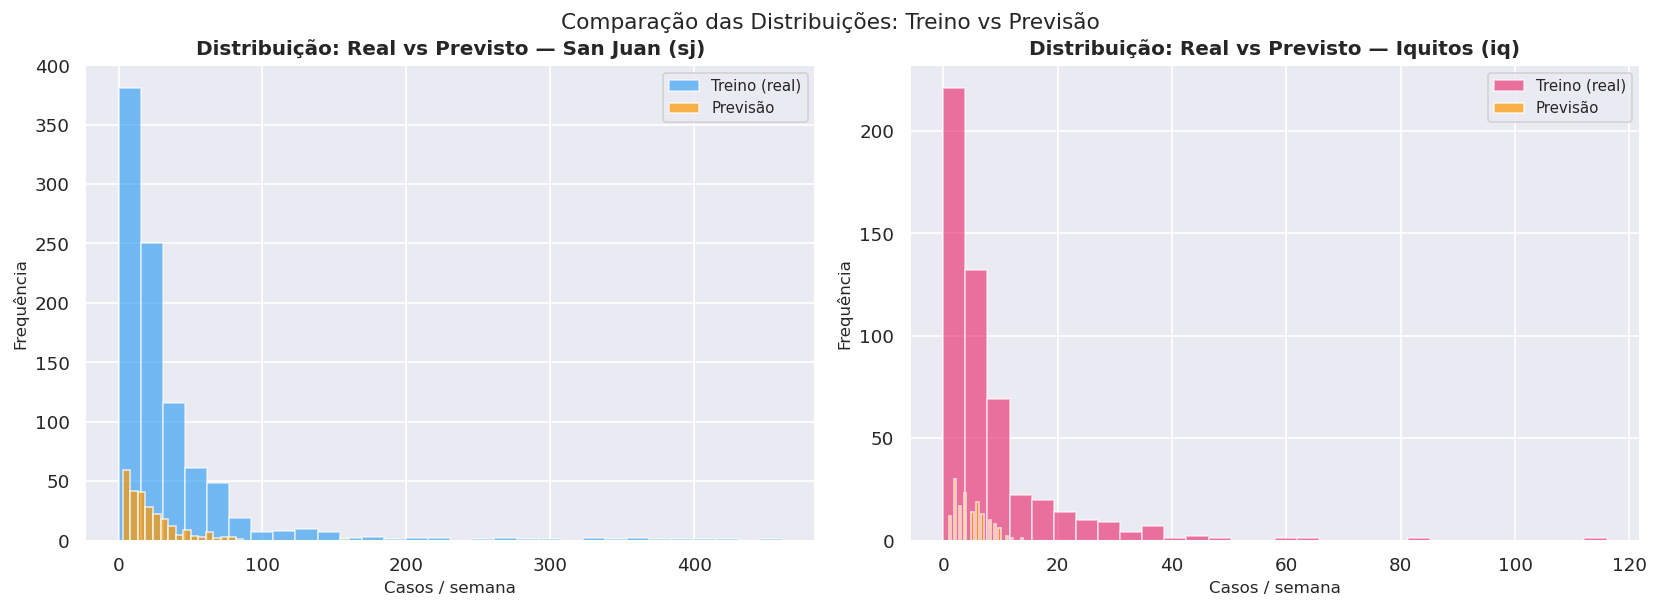

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

configs = [
    ('sj', train_sj, test_sj, preds_sj_int, 'San Juan (sj)', '#2196F3'),
    ('iq', train_iq, test_iq, preds_iq_int, 'Iquitos (iq)',  '#E91E63'),
]

for ax, (city, train_df, test_df, preds, label, cor) in zip(axes, configs):
    # Série de treino
    dates_train = pd.to_datetime(train_df['week_start_date'])
    ax.fill_between(dates_train, train_df['total_cases'],
                    alpha=0.25, color=cor)
    ax.plot(dates_train, train_df['total_cases'],
            color=cor, linewidth=0.8, label='Treino (real)', alpha=0.8)

    # Série de previsão
    dates_test = pd.to_datetime(test_df['week_start_date'])
    ax.fill_between(dates_test, preds, alpha=0.4, color='#FF9800')
    ax.plot(dates_test, preds, color='#FF6F00', linewidth=1.5,
            label='Previsão ensemble (teste)', zorder=5)

    # Linha vertical separando treino de teste
    ax.axvline(dates_train.iloc[-1], color='black', linestyle='--',
               linewidth=1, alpha=0.6, label='Fim do treino')

    ax.set_title(f'Previsão de Casos de Dengue — {label}', fontweight='bold')
    ax.set_xlabel('Data')
    ax.set_ylabel('Casos / semana')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Previsões do Ensemble sobre Dados de Teste',
             y=1.01, fontsize=14, fontweight='bold')
plt.show()

# Histograma de previsões vs histórico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, train_df, preds, label, cor in zip(
        axes,
        [train_sj, train_iq],
        [preds_sj_int, preds_iq_int],
        ['San Juan (sj)', 'Iquitos (iq)'],
        ['#2196F3', '#E91E63']):
    ax.hist(train_df['total_cases'], bins=30, color=cor, alpha=0.6, label='Treino (real)')
    ax.hist(preds, bins=30, color='#FF9800', alpha=0.7, label='Previsão')
    ax.set_title(f'Distribuição: Real vs Previsto — {label}', fontweight='bold')
    ax.set_xlabel('Casos / semana')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Comparação das Distribuições: Treino vs Previsão', y=1.01, fontsize=13)
plt.show()


### 5. Geração e Validação do Ficheiro de Submissão

O formato de submissão da DrivenData exige exactamente as colunas
`city`, `year`, `weekofyear`, `total_cases` — nesta ordem e sem colunas extra.




In [6]:
# Construir DataFrame de submissão
sub_sj = test_sj[['city', 'year', 'weekofyear']].copy()
sub_sj['total_cases'] = preds_sj_int

sub_iq = test_iq[['city', 'year', 'weekofyear']].copy()
sub_iq['total_cases'] = preds_iq_int

submission = pd.concat([sub_sj, sub_iq], ignore_index=True)
submission['total_cases'] = submission['total_cases'].astype(int)

# ── Validação contra submission_format.csv ──
print("── Validação do ficheiro de submissão ──\n")

# 1. Número de linhas
assert len(submission) == len(submission_format), \
    f"ERRO: {len(submission)} linhas, esperado {len(submission_format)}"
print(f"  Número de linhas: {len(submission)} ✓ (esperado: {len(submission_format)})")

# 2. Colunas correctas
assert list(submission.columns) == ['city', 'year', 'weekofyear', 'total_cases'], \
    "ERRO: colunas incorrectas"
print(f"  Colunas: {list(submission.columns)} ✓")

# 3. Sem NaN
assert submission.isnull().sum().sum() == 0, "ERRO: existem NaN"
print(f"  Missing values: 0 ✓")

# 4. Sem negativos
assert (submission['total_cases'] >= 0).all(), "ERRO: existem valores negativos"
print(f"  Valores negativos: 0 ✓")

# 5. Cidades correctas
assert set(submission['city'].unique()) == {'sj', 'iq'}, "ERRO: cidades incorrectas"
print(f"  Cidades: {sorted(submission['city'].unique())} ✓")

# 6. Verificar alignment com submission_format
merged = submission_format[['city','year','weekofyear']].merge(
    submission, on=['city','year','weekofyear'], how='left'
)
assert merged['total_cases'].isnull().sum() == 0, "ERRO: linhas em falta no submission"
print(f"  Alinhamento com submission_format.csv ✓")

print(f"\nTodas as validações passaram com sucesso!")
print(f"\n── Primeiras 10 linhas da submissão ──")
print(submission.head(10).to_string(index=False))


── Validação do ficheiro de submissão ──

  Número de linhas: 416 ✓ (esperado: 416)
  Colunas: ['city', 'year', 'weekofyear', 'total_cases'] ✓
  Missing values: 0 ✓
  Valores negativos: 0 ✓
  Cidades: ['iq', 'sj'] ✓
  Alinhamento com submission_format.csv ✓

Todas as validações passaram com sucesso!

── Primeiras 10 linhas da submissão ──
city  year  weekofyear  total_cases
  sj  2008          18            5
  sj  2008          19            4
  sj  2008          20            6
  sj  2008          21            6
  sj  2008          22            5
  sj  2008          23            5
  sj  2008          24            8
  sj  2008          25            9
  sj  2008          26           10
  sj  2008          27           12


In [7]:
# Guardar submission.csv
submission.to_csv('submission.csv', index=False)
print(f"Ficheiro de submissão guardado: submission.csv")
print(f"Shape final: {submission.shape}")
print(f"\n── Estatísticas finais da submissão ──")
for city in ['sj', 'iq']:
    sub = submission[submission['city'] == city]['total_cases']
    print(f"\n  {city}:")
    print(f"    Semanas previstas: {len(sub)}")
    print(f"    Mínimo:  {sub.min()} casos/semana")
    print(f"    Máximo:  {sub.max()} casos/semana")
    print(f"    Média:   {sub.mean():.1f} casos/semana")
    print(f"    Mediana: {sub.median():.0f} casos/semana")
    print(f"    Total de casos previstos: {sub.sum()}")


Ficheiro de submissão guardado: submission.csv
Shape final: (416, 4)

── Estatísticas finais da submissão ──

  sj:
    Semanas previstas: 260
    Mínimo:  3 casos/semana
    Máximo:  160 casos/semana
    Média:   22.7 casos/semana
    Mediana: 16 casos/semana
    Total de casos previstos: 5903

  iq:
    Semanas previstas: 156
    Mínimo:  1 casos/semana
    Máximo:  14 casos/semana
    Média:   4.8 casos/semana
    Mediana: 4 casos/semana
    Total de casos previstos: 750


### 6. Série Temporal Completa — Treino + Inferência Futura

Visualização da série temporal **completa** para cada cidade:
todo o histórico de treino (casos reais observados) concatenado com as previsões
do ensemble para o período de teste (inferência futura).


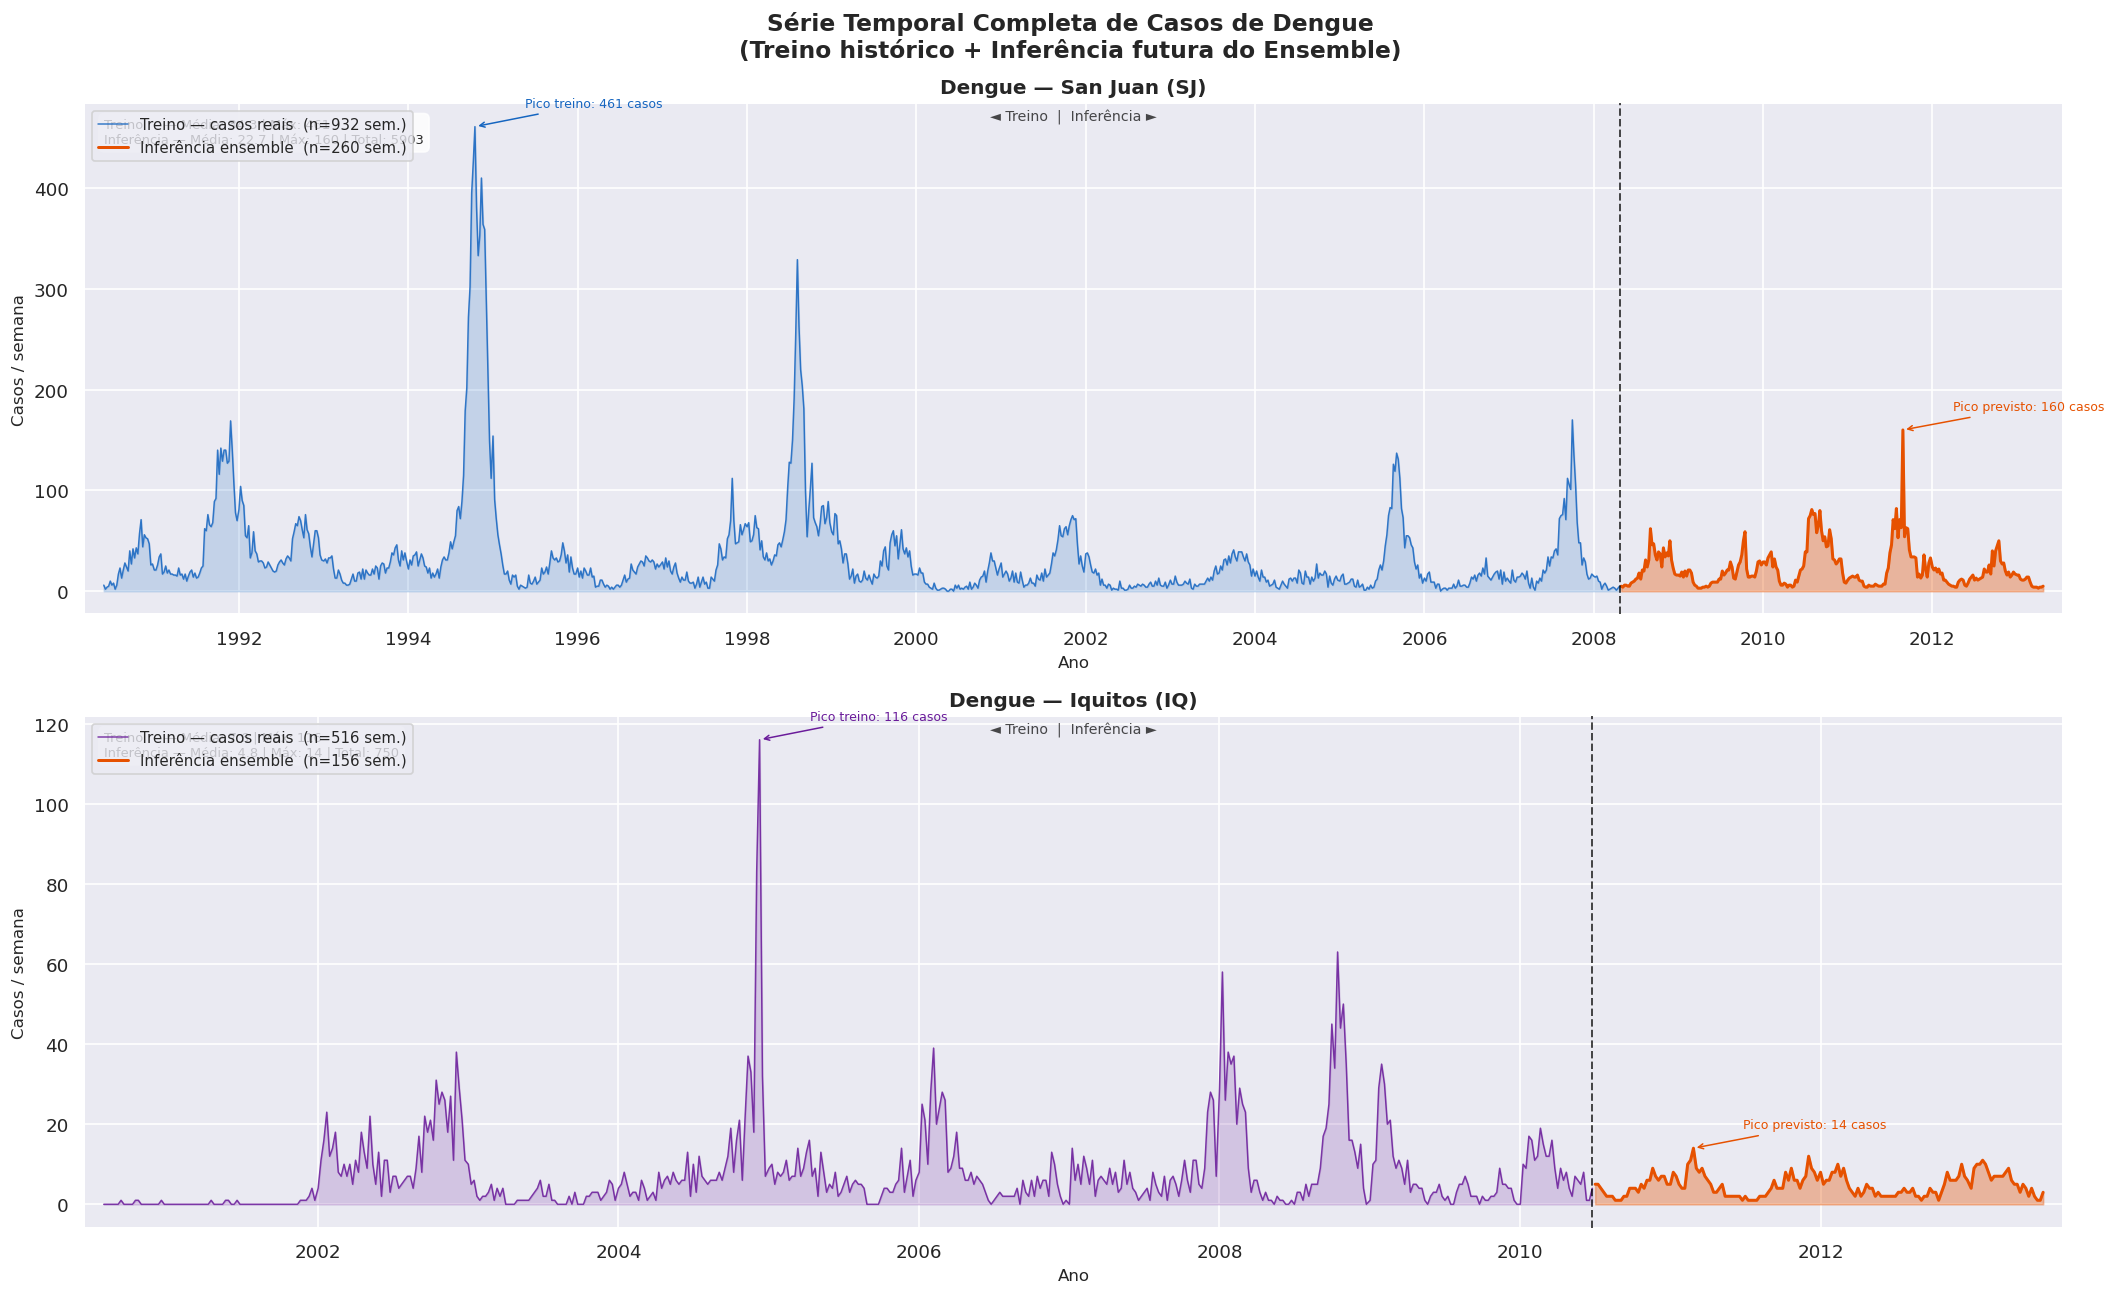

Gráfico guardado em: series_completa_dengue.png


In [11]:
# ── Série temporal completa: treino + inferência futura ───────────────────────
import matplotlib.dates as mdates

configs = [
    dict(train=train_sj, test=test_sj, preds=preds_sj_int,
         label='San Juan (SJ)', cor_treino='#1565C0', cor_pred='#E65100'),
    dict(train=train_iq, test=test_iq, preds=preds_iq_int,
         label='Iquitos (IQ)',  cor_treino='#6A1B9A', cor_pred='#E65100'),
]

fig, axes = plt.subplots(2, 1, figsize=(18, 11), sharex=False)
fig.suptitle(
    'Série Temporal Completa de Casos de Dengue\n'
    '(Treino histórico + Inferência futura do Ensemble)',
    fontsize=14, fontweight='bold'
)

for ax, cfg in zip(axes, configs):
    train_df = cfg['train']
    test_df  = cfg['test']
    preds    = cfg['preds']
    cor_t    = cfg['cor_treino']
    cor_p    = cfg['cor_pred']

    dates_train = pd.to_datetime(train_df['week_start_date'])
    dates_test  = pd.to_datetime(test_df['week_start_date'])
    n_train, n_test = len(dates_train), len(dates_test)

    # ── Série de treino ─────────────────────────────────────────────────────
    ax.fill_between(dates_train, train_df['total_cases'], alpha=0.18, color=cor_t)
    ax.plot(dates_train, train_df['total_cases'],
            color=cor_t, linewidth=0.9, alpha=0.85,
            label=f'Treino — casos reais  (n={n_train} sem.)')

    # ── Previsões ensemble ──────────────────────────────────────────────────
    ax.fill_between(dates_test, preds, alpha=0.35, color=cor_p)
    ax.plot(dates_test, preds,
            color=cor_p, linewidth=1.8, zorder=5,
            label=f'Inferência ensemble  (n={n_test} sem.)')

    # ── Linha vertical de separação ─────────────────────────────────────────
    limite = dates_train.iloc[-1]
    ax.axvline(limite, color='black', linestyle='--', linewidth=1.2,
               alpha=0.7, zorder=6)
    # Rótulo em coordenadas de fracção do eixo (0-1) — sem mistura com 'data'
    ax.text(0.50, 0.99, '◄ Treino  |  Inferência ►',
            transform=ax.transAxes,
            fontsize=8.5, ha='center', va='top', alpha=0.70, color='black')

    # ── Anotação: pico máximo no treino ─────────────────────────────────────
    iloc_tr = int(train_df['total_cases'].values.argmax())
    x_tr = dates_train.iloc[iloc_tr]
    y_tr = int(train_df['total_cases'].iloc[iloc_tr])
    ax.annotate(f'Pico treino: {y_tr} casos',
                xy=(x_tr, y_tr),
                xytext=(30, 12), textcoords='offset points',
                fontsize=7.5, color=cor_t,
                arrowprops=dict(arrowstyle='->', color=cor_t, lw=0.9))

    # ── Anotação: pico máximo na inferência ─────────────────────────────────
    iloc_pr = int(preds.argmax())
    x_pr = dates_test.iloc[iloc_pr]
    y_pr = int(preds[iloc_pr])
    ax.annotate(f'Pico previsto: {y_pr} casos',
                xy=(x_pr, y_pr),
                xytext=(30, 12), textcoords='offset points',
                fontsize=7.5, color=cor_p,
                arrowprops=dict(arrowstyle='->', color=cor_p, lw=0.9))

    # ── Caixa de estatísticas ───────────────────────────────────────────────
    stats_txt = (
        f"Treino     — Média: {train_df['total_cases'].mean():.1f}"
        f" | Máx: {train_df['total_cases'].max()}\n"
        f"Inferência — Média: {preds.mean():.1f}"
        f" | Máx: {preds.max()} | Total: {int(preds.sum())}"
    )
    ax.text(0.01, 0.97, stats_txt,
            transform=ax.transAxes, fontsize=7.8,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.82))

    # ── Formatação dos eixos ────────────────────────────────────────────────
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_title(f'Dengue — {cfg["label"]}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Casos / semana', fontsize=10)
    ax.set_xlabel('Ano', fontsize=10)
    ax.legend(fontsize=9, loc='upper left')
    ax.margins(x=0.01)

plt.tight_layout()
plt.savefig('series_completa_dengue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado em: series_completa_dengue.png")
